Before comparing the unweighted and reweighted models, I applied a targeted reweighting strategy to address fairness concerns for high-income women, who represent only 3.6% of the training data (877 out of 24,129 samples). Rather than upweighting the entire high-income class, I specifically boosted high-income women by a factor of approximately 5× to match the effective representation of high-income men during training. All weights were then normalized to sum to the total number of training samples, ensuring the boosted group had equal influence to the reference group.


However, this reweighting strategy backfired. Recall for high-income women declined substantially across all models—from 64.7% to 28.1% for Logistic Regression and from 50.2% to 31.9% for Gradient Boosting. Rather than learning better patterns for the target group, the models became overly conservative, defaulting to predicting low-income for uncertain cases to minimize the heavily weighted misclassification penalty. While overall accuracy increased (e.g., 73.5% to 79.9% for Logistic Regression), this improvement came entirely from better prediction of the majority low-income class, making the fairness problem worse rather than better. These results suggest that with only 877 high-income women in the training set, sample reweighting cannot overcome the fundamental challenge of learning robust patterns from such limited data. Consequently, I shifted focus toward post-processing techniques, such as threshold adjustment, which can improve fairness without requiring the model to learn from insufficient training examples

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
import os
import json
import pandas as pd

comparison_data = {
    'Logistic Regression': {},
    'Random Forest': {},
    'Gradient Boosting': {}
}

results_path = "../outputs/results/"
all_files = [f for f in os.listdir(results_path) if f.endswith('.json') and f != "fairness_metrics.json" and f != 'sample_weight.json']

for file_name in all_files:
    
    # Determine if the file is reweighed or unweighed
    if '_reweighted' in file_name:
        model_key = file_name.replace(".json", "")
        model_name = model_key.replace('_reweighted', '')
        result_type = 'reweighed'
        
    else:
        model_name = file_name.replace(".json", "")
        model_key = model_name 
        result_type = 'unweighed'

    # Load data and assign it to correct comparison slot
    if model_name in comparison_data:
        full_path = os.path.join(results_path, file_name)
        
        # Check if we've already loaded this result type for this model
        if result_type not in comparison_data[model_name]:
            
            with open(full_path, 'r') as f:
                data = json.load(f)
                comparison_data[model_name][result_type] = data.get(model_key, data)

pd.set_option('display.max_colwidth', None)

# Load Dataframes
logreg_df = pd.DataFrame({
    'reweighed': comparison_data['Logistic Regression'].get('reweighed', {}),
    'unweighed': comparison_data['Logistic Regression'].get('unweighed', {})
})

ranforest_df = pd.DataFrame({
    'reweighed': comparison_data['Random Forest'].get('reweighed', {}),
    'unweighed': comparison_data['Random Forest'].get('unweighed', {})
})

gb_df = pd.DataFrame({
    'reweighed': comparison_data['Gradient Boosting'].get('reweighed', {}),
    'unweighed': comparison_data['Gradient Boosting'].get('unweighed', {})
})

print("\nLogistic Regression Comparison")
print(logreg_df)

print("\nRandom Forest Comparison")
print(ranforest_df)

print("\nGradient Boosting Comparison")
print(gb_df)



Logistic Regression Comparison
                                                                                                                       reweighed  \
0               {'precision': 0.8217610550814585, 'recall': 0.93511366144339, 'f1-score': 0.8747806338391659, 'support': 4531.0}   
1             {'precision': 0.6647662485746865, 'recall': 0.3881491344873502, 'f1-score': 0.4901218999579655, 'support': 1502.0}   
accuracy                                                                                                                0.798939   
macro avg     {'precision': 0.7432636518280724, 'recall': 0.6616313979653701, 'f1-score': 0.6824512668985657, 'support': 6033.0}   
weighted avg  {'precision': 0.7826749951820434, 'recall': 0.7989391679098292, 'f1-score': 0.7790144448304533, 'support': 6033.0}   

                                                                                                                       unweighed  
0             {'precision': 0.90062790062790

weighted model performance on high-income women Gradient Boosting_reweighted_preds.npz:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.32      0.48       235

    accuracy                           0.32       235
   macro avg       0.50      0.16      0.24       235
weighted avg       1.00      0.32      0.48       235

weighted model performance on high-income women Logistic Regression_reweighted_preds.npz:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.28      0.44       235

    accuracy                           0.28       235
   macro avg       0.50      0.14      0.22       235
weighted avg       1.00      0.28      0.44       235

weighted model performance on high-income women Random Forest_reweighted_preds.npz:
              precision    recall  f1-score   support

           0       0.00      

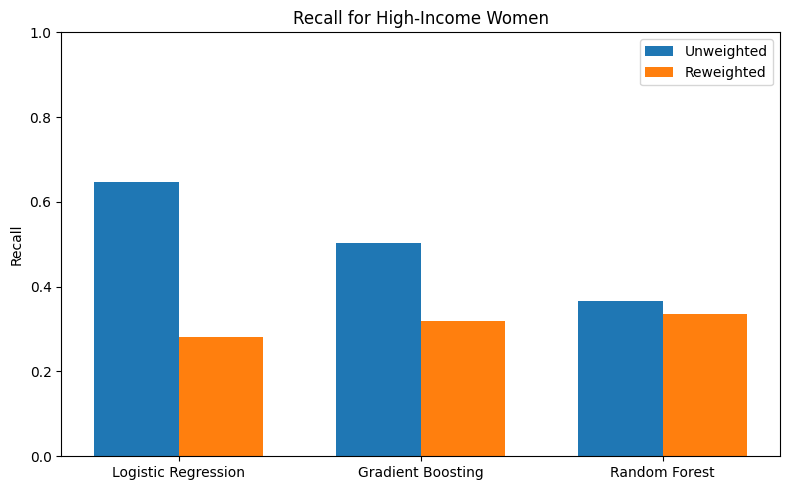

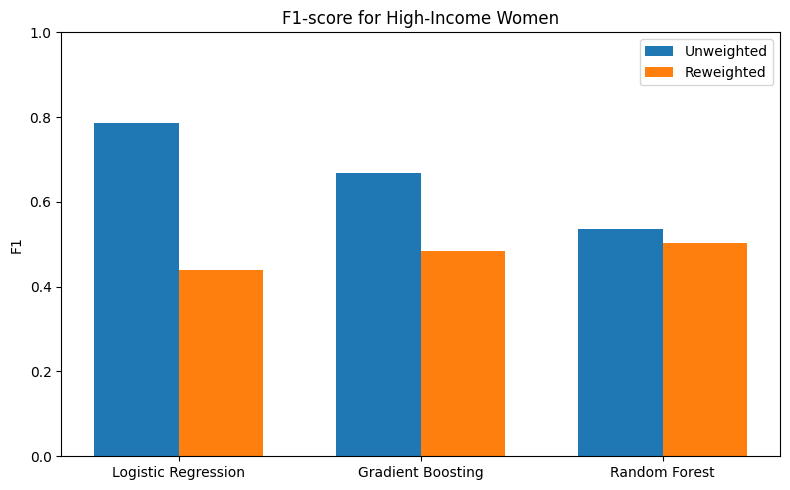

In [3]:
# Finding the impact of reweighing on the high-income women minority
import sys
import os
sys.path.append(os.path.abspath(".."))
from utils import eval_helper as ev
from utils import plot_helper as plot

# Model filenames
model_pairs = [
    ("Logistic Regression_preds.npz", "Logistic Regression_reweighted_preds.npz"),
    ("Gradient Boosting_preds.npz", "Gradient Boosting_reweighted_preds.npz"),
    ("Random Forest_preds.npz", "Random Forest_reweighted_preds.npz")
]

results = []
for unweighted, reweighted in model_pairs:
    base = unweighted.split("_preds")[0]
    results.append(ev.evaluate_high_income_women(f"../outputs/preds/{unweighted}", base + " (Unweighted)"))
    results.append(ev.evaluate_high_income_women(f"../outputs/preds/{reweighted}", base + " (Reweighted)"))

plot.plot_metric_comparison(results, "recall", "Recall for High-Income Women")
plot.plot_metric_comparison(results, "f1", "F1-score for High-Income Women")

In [7]:
for baseline_file, reweighted_file in model_pairs:
    model_name = baseline_file.replace("_preds.npz", "")
    
    print(f"\n{'='*80}")
    print(f"{model_name.upper()}")
    print(f"{'='*80}")
    
    for label, filename in [('BASELINE', baseline_file), ('REWEIGHTED', reweighted_file)]:
        path_npz = os.path.join('../outputs/preds/', filename)
        data = np.load(path_npz)
        y_test = data["y_test"]
        y_pred = data["y_pred"]
        s_test = data["s_test"]
        
        print(f"\n--- {label} ---")
        
        # High-income women (target group)
        mask_hiw = (s_test == 0) & (y_test == 1)
        print(f"High-income WOMEN: Total={mask_hiw.sum()}, Correctly predicted={((y_pred==1) & mask_hiw).sum()}, Recall={((y_pred==1) & mask_hiw).sum() / mask_hiw.sum():.3f}")
        
        # High-income men (comparison group)
        mask_him = (s_test == 1) & (y_test == 1)
        print(f"High-income MEN:   Total={mask_him.sum()}, Correctly predicted={((y_pred==1) & mask_him).sum()}, Recall={((y_pred==1) & mask_him).sum() / mask_him.sum():.3f}")
        
        # Low-income women
        mask_liw = (s_test == 0) & (y_test == 0)
        print(f"Low-income WOMEN:  Total={mask_liw.sum()}, Correctly predicted={((y_pred==0) & mask_liw).sum()}, Specificity={((y_pred==0) & mask_liw).sum() / mask_liw.sum():.3f}")
        
        # Low-income men
        mask_lim = (s_test == 1) & (y_test == 0)
        print(f"Low-income MEN:    Total={mask_lim.sum()}, Correctly predicted={((y_pred==0) & mask_lim).sum()}, Specificity={((y_pred==0) & mask_lim).sum() / mask_lim.sum():.3f}")


LOGISTIC REGRESSION

--- BASELINE ---
High-income WOMEN: Total=235, Correctly predicted=152, Recall=0.647
High-income MEN:   Total=1267, Correctly predicted=986, Recall=0.778
Low-income WOMEN:  Total=1733, Correctly predicted=1326, Specificity=0.765
Low-income MEN:    Total=2798, Correctly predicted=1973, Specificity=0.705

--- REWEIGHTED ---
High-income WOMEN: Total=235, Correctly predicted=66, Recall=0.281
High-income MEN:   Total=1267, Correctly predicted=517, Recall=0.408
Low-income WOMEN:  Total=1733, Correctly predicted=1640, Specificity=0.946
Low-income MEN:    Total=2798, Correctly predicted=2597, Specificity=0.928

GRADIENT BOOSTING

--- BASELINE ---
High-income WOMEN: Total=235, Correctly predicted=118, Recall=0.502
High-income MEN:   Total=1267, Correctly predicted=889, Recall=0.702
Low-income WOMEN:  Total=1733, Correctly predicted=1430, Specificity=0.825
Low-income MEN:    Total=2798, Correctly predicted=2199, Specificity=0.786

--- REWEIGHTED ---
High-income WOMEN: Total

The reweighting strategy failed to achieve its goal of improving predictions for high-income women. While overall accuracy increased (73.5% to 79.9% for Logistic Regression, 76.8% to 80.7% for Gradient Boosting), this improvement was misleading—it came entirely from better prediction of the majority low-income class. Performance on the target group collapsed: recall for high-income women dropped from 64.7% to 28.1% for Logistic Regression and from 50.2% to 31.9% for Gradient Boosting. Instead of learning better patterns for the underrepresented group, the models became overly conservative, defaulting to predicting low-income to avoid the heavily weighted misclassification penalty. This result demonstrates that sample reweighting alone cannot overcome the fundamental challenge of learning from only 877 high-income women (3.6% of training data).
